# Capítulo 34 — Visualizar distribuciones

## Mirar cómo se reparten los valores

En el capítulo anterior analizamos los datos según una dimensión temporal simple.

Usamos las columnas `day` y `time` para comparar cantidades, totales y promedios según el día y el horario. Ahora vamos a cambiar el foco.

En lugar de preguntarnos cómo cambian los datos entre momentos, vamos a observar cómo se distribuyen los valores de una variable numérica. Por ejemplo:

**¿la mayoría de las cuentas tienen importes bajos, medios o altos?**

**¿hay muchas cuentas parecidas entre sí?**

**¿aparecen algunos valores mucho más grandes que el resto?**

Para responder este tipo de preguntas vamos a empezar a usar gráficos de distribución.

En este capítulo trabajaremos principalmente con la columna `total_bill`, que representa el importe total de cada cuenta.

## ¿Qué significa visualizar una distribución?

Cuando analizamos una columna numérica, no siempre alcanza con calcular un promedio. El promedio resume muchos datos en un solo número, pero no nos muestra cómo están repartidos los valores.

Dos columnas pueden tener promedios parecidos y, sin embargo, distribuciones muy diferentes. Visualizar una distribución significa observar cómo se reparten los valores de una variable:

- qué valores aparecen con más frecuencia;
- si los datos están concentrados o dispersos;
- si hay valores muy pequeños o muy grandes;
- si aparecen valores extremos.

Para empezar, vamos a cargar nuevamente el dataset `tips`.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


La salida muestra las primeras filas del dataset `tips`.

Cada fila representa una cuenta registrada en un restaurante. En este capítulo vamos a concentrarnos especialmente en la columna `total_bill`, que indica el importe total de cada cuenta. Esta columna es numérica, por lo que podemos analizarla de varias maneras:

* podemos calcular medidas de resumen, como el promedio o la mediana;
* podemos buscar valores mínimos y máximos;
* y también podemos visualizar cómo se reparten sus valores.

Ese último punto será el eje principal del capítulo.

## Empezar con una variable numérica

Antes de hacer un gráfico, conviene mirar algunos valores de resumen. Esto nos ayuda a tener una primera idea de la variable que vamos a visualizar. Vamos a calcular un resumen estadístico de la columna `total_bill`.

Este resumen nos mostrará valores como:

- la cantidad de datos;
- el promedio;
- el valor mínimo;
- los cuartiles;
- el valor máximo.

Después vamos a comparar esta información con lo que se ve en un gráfico de distribución.

In [ ]:
df["total_bill"].describe().round(2)

,total_bill
count,244.00
mean,19.79
std,8.90
min,3.07
25%,13.35
50%,17.80
75%,24.13
max,50.81


El resumen estadístico de `total_bill` nos da una primera idea de cómo son los importes de las cuentas. En el dataset hay 244 cuentas registradas.

El importe promedio de una cuenta es 19.79, mientras que la mediana es 17.80. Recordemos que la mediana corresponde al valor central: aproximadamente la mitad de las cuentas tienen un importe menor o igual a 17.80, y la otra mitad tiene un importe mayor o igual.

También podemos observar que:

- el valor mínimo es 3.07;
- el 25% de las cuentas tiene un importe menor o igual a 13.35;
- el 75% de las cuentas tiene un importe menor o igual a 24.13;
- el valor máximo es 50.81.

Estos números son útiles, pero todavía no nos muestran con claridad cómo se reparten los valores.

Para eso vamos a construir nuestro primer gráfico de distribución.

## Primer gráfico de distribución: histograma

Un histograma sirve para visualizar cómo se distribuyen los valores de una variable numérica.La idea es dividir el rango de valores en intervalos y contar cuántos datos caen dentro de cada intervalo.

En nuestro caso, vamos a usar un histograma para observar cómo se reparten los importes de la columna `total_bill`.Este gráfico nos puede ayudar a responder preguntas como:

**¿la mayoría de las cuentas se concentra en valores bajos, medios o altos?**

**¿hay muchos valores grandes?**

**¿los valores están repartidos de manera pareja o se concentran en una zona?**

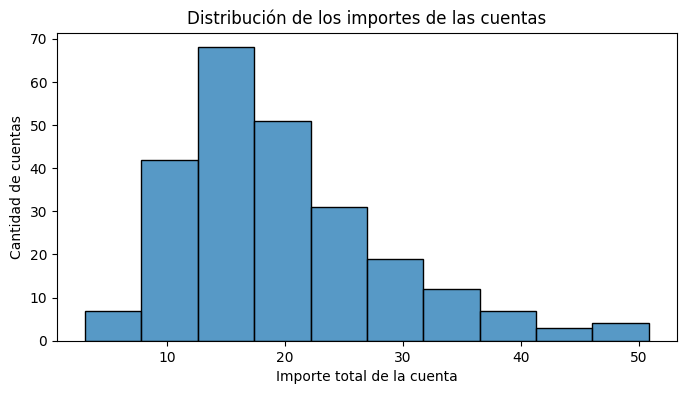

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="total_bill",
    bins=10
)

plt.title("Distribución de los importes de las cuentas")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Cantidad de cuentas")

plt.show()

El histograma muestra cómo se distribuyen los importes de las cuentas.

En el eje horizontal aparecen los valores de `total_bill`, es decir, los importes totales de las cuentas.

En el eje vertical aparece la cantidad de cuentas que caen dentro de cada intervalo.

La mayor concentración de cuentas se encuentra aproximadamente entre 10 y 25. Esto significa que la mayoría de los importes registrados están en esa zona.

También se observa que hay menos cuentas a medida que los importes son más altos. Hacia la derecha del gráfico aparecen algunas cuentas con valores mayores, cercanos a 40 o 50, pero son poco frecuentes.

Esta forma nos sugiere que la distribución no es simétrica: hay muchas cuentas de valores bajos o medios, y unas pocas cuentas bastante más altas.

## Leer la estructura del histograma

En la celda anterior usamos `sns.histplot()`.

La instrucción principal fue:

`sns.histplot(data=df, x="total_bill", bins=10)`

El argumento `data=df` indica qué DataFrame vamos a usar.

El argumento `x="total_bill"` indica qué columna queremos visualizar.

El argumento `bins=10` indica en cuántos intervalos se divide el rango de valores.

En un histograma, cada barra representa un intervalo de valores, no un valor individual.

Por ejemplo, una barra puede representar cuentas entre cierto importe mínimo y cierto importe máximo. La altura de esa barra indica cuántas cuentas caen dentro de ese intervalo.

Por eso, el histograma no se lee igual que un gráfico de barras categórico. En un gráfico de barras categórico, cada barra representa una categoría. En un histograma, cada barra representa un rango de valores numéricos.

## Cambiar la cantidad de intervalos

El argumento `bins` puede modificar bastante la apariencia del histograma. Si usamos pocos intervalos, el gráfico queda más resumido. Si usamos más intervalos, aparecen más detalles, pero también puede ser más difícil leer una forma general.

Vamos a repetir el histograma usando más intervalos para observar qué cambia.

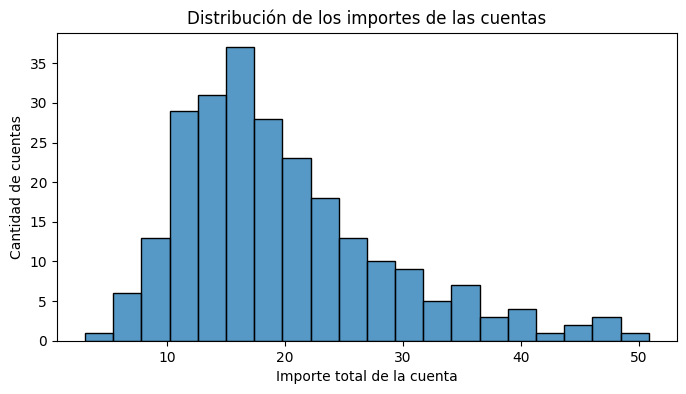

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="total_bill",
    bins=20
)

plt.title("Distribución de los importes de las cuentas")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Cantidad de cuentas")

plt.show()

Al aumentar la cantidad de intervalos, el histograma muestra más detalle. La forma general se mantiene: la mayor concentración de cuentas sigue apareciendo aproximadamente entre 10 y 25; hay menos cuentas a medida que los importes son más altos; y aparecen algunos valores grandes hacia la derecha del gráfico.

Este segundo histograma permite ver mejor que la distribución tiene una cola hacia la derecha. Esto significa que la mayoría de los valores se concentra en importes bajos o medios, mientras que unos pocos valores más altos se extienden hacia la derecha del gráfico.

Por eso, en el resumen estadístico anterior, el promedio era 19.79 y la mediana era 17.80.

Cuando hay algunos valores altos, el promedio puede quedar un poco más elevado que la mediana.

## Marcar el promedio y la mediana

Una forma útil de conectar una tabla de resumen con un gráfico es marcar algunos valores importantes sobre la visualización.

Vamos a volver a graficar la distribución de `total_bill`, pero esta vez vamos a agregar dos líneas verticales:

* una línea para el promedio;
* otra línea para la mediana.

Esto nos va a permitir observar dónde quedan ubicados esos valores dentro de la distribución.

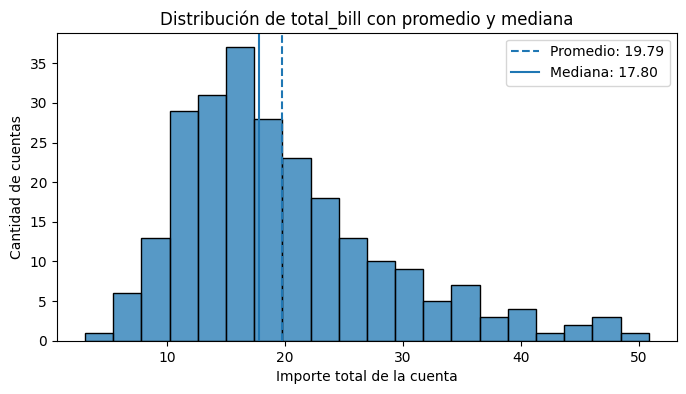

In [ ]:
promedio_total = df["total_bill"].mean()
mediana_total = df["total_bill"].median()

plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="total_bill",
    bins=20
)

plt.axvline(
    promedio_total,
    linestyle="--",
    label=f"Promedio: {promedio_total:.2f}"
)

plt.axvline(
    mediana_total,
    linestyle="-",
    label=f"Mediana: {mediana_total:.2f}"
)

plt.title("Distribución de total_bill con promedio y mediana")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Cantidad de cuentas")
plt.legend()

plt.show()

El histograma muestra nuevamente la distribución de `total_bill`, pero ahora agregamos dos líneas verticales.

* La línea punteada marca el promedio: 19.79.
* La línea continua marca la mediana: 17.80.

Se puede observar que el promedio queda un poco más a la derecha que la mediana. Esto coincide con lo que vimos antes: la distribución tiene varios valores altos hacia la derecha. Esos valores altos empujan el promedio hacia arriba.

La mediana, en cambio, representa el valor central de los datos y suele verse menos afectada por algunos valores grandes.

Por eso, cuando una distribución tiene una cola hacia la derecha, es común que el promedio sea mayor que la mediana.

## Cómo agregamos líneas de referencia

En la celda anterior usamos algunas instrucciones nuevas.

Primero calculamos dos valores:

`promedio_total = df["total_bill"].mean()`

`mediana_total = df["total_bill"].median()`

La primera línea calcula el promedio de la columna `total_bill`.

La segunda línea calcula la mediana de esa misma columna.

Después usamos `plt.axvline()` para dibujar líneas verticales sobre el gráfico. Por ejemplo:

`plt.axvline(promedio_total, linestyle="--", label=f"Promedio: {promedio_total:.2f}")`

Esta instrucción agrega una línea vertical en la posición del promedio.

El argumento `linestyle="--"` indica que la línea se dibuja con estilo punteado.

El argumento `label` define el texto que aparecerá en la leyenda.

La parte `f"Promedio: {promedio_total:.2f}"` permite construir un texto que incluye el valor del promedio con dos decimales.

También usamos:

`plt.legend()`

Esta instrucción muestra la leyenda del gráfico. La leyenda sirve para identificar qué representa cada línea.

## Otra forma de visualizar la distribución: boxplot

El histograma nos ayuda a ver la forma general de una distribución. Ahora vamos a usar otro gráfico muy común para analizar variables numéricas: el boxplot, también llamado diagrama de caja.

Un boxplot permite observar de manera compacta:

- la mediana;
- el rango donde se concentra la mitad central de los datos;
- los bigotes, que muestran hasta dónde llegan los valores que no se consideran extremos según el criterio del gráfico;
- posibles valores extremos.

Este tipo de gráfico es especialmente útil cuando queremos detectar si hay valores alejados del resto.

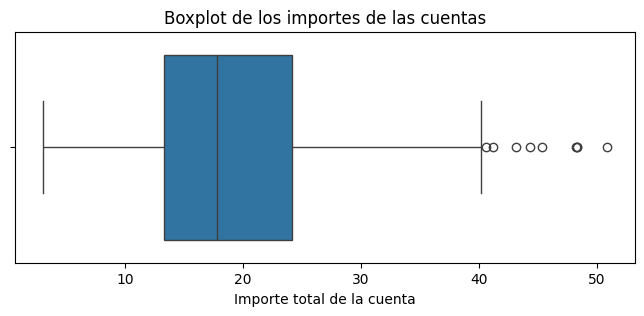

In [ ]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="total_bill"
)

plt.title("Boxplot de los importes de las cuentas")
plt.xlabel("Importe total de la cuenta")

plt.show()

El boxplot muestra la distribución de `total_bill` de una manera más resumida que el histograma.

La caja representa la zona donde se concentra la mitad central de los datos. En este caso, la caja se extiende aproximadamente desde 13.35 hasta 24.13. Esto coincide con los valores del primer y tercer cuartil que vimos en el resumen estadístico. La línea dentro de la caja marca la mediana, que era 17.80.

También se observa que el lado derecho del gráfico se extiende más que el izquierdo. Esto vuelve a mostrar que hay algunos importes bastante más altos que la mayoría de las cuentas.

Los puntos que aparecen hacia la derecha, aproximadamente por encima de 40, representan posibles valores extremos. No significa necesariamente que sean errores, sino que son cuentas más alejadas del comportamiento general del dataset.

## Cómo leer un boxplot

Un boxplot resume una variable numérica usando algunas referencias importantes.

* La caja muestra el rango donde se encuentra la mitad central de los datos.
* El borde izquierdo de la caja representa el primer cuartil. En este caso, corresponde aproximadamente a 13.35.
* El borde derecho de la caja representa el tercer cuartil. En este caso, corresponde aproximadamente a 24.13.
* La línea dentro de la caja representa la mediana. En este caso, la mediana es 17.80.
* Las líneas que salen de la caja se llaman bigotes. Sirven para mostrar hasta dónde llegan los valores que todavía se consideran dentro del rango esperado según el criterio del gráfico.
* Los puntos que aparecen fuera de los bigotes son posibles valores extremos.

Este tipo de gráfico es útil porque permite ver rápidamente la concentración central de los datos, la posición de la mediana y la presencia de valores alejados.

## Conectar el boxplot con los valores numéricos

Para interpretar mejor el boxplot, podemos recuperar algunos valores que ya aparecieron en el resumen estadístico.

Vamos a calcular:

- primer cuartil;
- mediana;
- tercer cuartil;
- rango intercuartílico.

El rango intercuartílico mide la distancia entre el tercer cuartil y el primer cuartil.

Nos ayuda a describir cuán extendida está la mitad central de los datos.

In [ ]:
q1 = df["total_bill"].quantile(0.25)
mediana = df["total_bill"].median()
q3 = df["total_bill"].quantile(0.75)
rango_intercuartilico = q3 - q1

resumen_boxplot = pd.DataFrame({
    "indicador": [
        "Primer cuartil",
        "Mediana",
        "Tercer cuartil",
        "Rango intercuartílico"
    ],
    "valor": [
        q1,
        mediana,
        q3,
        rango_intercuartilico
    ]
})

resumen_boxplot["valor"] = resumen_boxplot["valor"].round(2)

resumen_boxplot

,indicador,valor
0,Primer cuartil,13.35
1,Mediana,17.80
2,Tercer cuartil,24.13
3,Rango intercuartílico,10.78


La tabla muestra algunos valores clave para interpretar el boxplot.

El primer cuartil es 13.35. Esto significa que el 25% de las cuentas tiene un importe menor o igual a 13.35.

La mediana es 17.80. Esto indica que la mitad de las cuentas tiene un importe menor o igual a 17.80, y la otra mitad tiene un importe mayor o igual.

El tercer cuartil es 24.13. Esto significa que el 75% de las cuentas tiene un importe menor o igual a 24.13.

El rango intercuartílico es 10.78. Este valor surge de restar el primer cuartil al tercer cuartil:

24.13 - 13.35 = 10.78

Ese rango describe la amplitud de la mitad central de los datos. En otras palabras, la mitad central de las cuentas se encuentra aproximadamente entre 13.35 y 24.13.


## Histograma y boxplot: dos miradas complementarias

El histograma y el boxplot muestran la misma variable, pero de formas distintas. El histograma permite ver la forma general de la distribución. Nos muestra en qué zonas se concentran más valores y si hay una cola hacia alguno de los lados.

El boxplot resume esa distribución en pocos elementos: cuartiles, mediana, bigotes y posibles valores extremos.

En este caso, ambos gráficos cuentan una historia parecida:

* la mayoría de las cuentas se concentra en valores bajos o medios;
* la mitad central de los datos está aproximadamente entre 13.35 y 24.13;
* la mediana está en 17.80;
* y hay algunos importes altos que aparecen alejados del grupo principal.

Usar ambos gráficos juntos ayuda a interpretar mejor la variable. El histograma muestra la forma; el boxplot resume la posición, la dispersión y los posibles valores extremos.

## Aplicar la misma idea a otra variable: propinas

Hasta ahora analizamos la distribución de `total_bill`. Para reforzar la idea, vamos a mirar otra variable numérica del dataset: `tip`.

La columna `tip` representa el monto de la propina.

Vamos a seguir el mismo camino: primero calculamos un resumen estadístico;
después visualizamos la distribución con un histograma; y luego usamos un boxplot para observar la mediana, los cuartiles y posibles valores extremos.

In [ ]:
df["tip"].describe().round(2)

,tip
count,244.00
mean,3.00
std,1.38
min,1.00
25%,2.00
50%,2.90
75%,3.56
max,10.00


El resumen estadístico de `tip` muestra cómo se comportan las propinas registradas en el dataset. Hay 244 propinas, una por cada cuenta.

El promedio de propina es 3.00, mientras que la mediana es 2.90. En este caso, ambos valores están bastante cerca.

También podemos observar que:

- la propina mínima es 1.00;
- el 25% de las propinas es menor o igual a 2.00;
- el 50% de las propinas es menor o igual a 2.90;
- el 75% de las propinas es menor o igual a 3.56;
- la propina máxima es 10.00.

La mayor parte de las propinas parece ubicarse en valores relativamente bajos, entre 2 y 4 aproximadamente.

Pero para observar mejor cómo se reparten esos valores, conviene construir un histograma.

## Histograma de las propinas

Vamos a visualizar ahora la distribución de la columna `tip`. La pregunta que queremos responder es:

**¿cómo se reparten los valores de las propinas?**

Este gráfico nos permitirá observar si la mayoría de las propinas se concentra en una zona, si hay valores altos poco frecuentes y si la distribución tiene una forma parecida o diferente a la de `total_bill`.

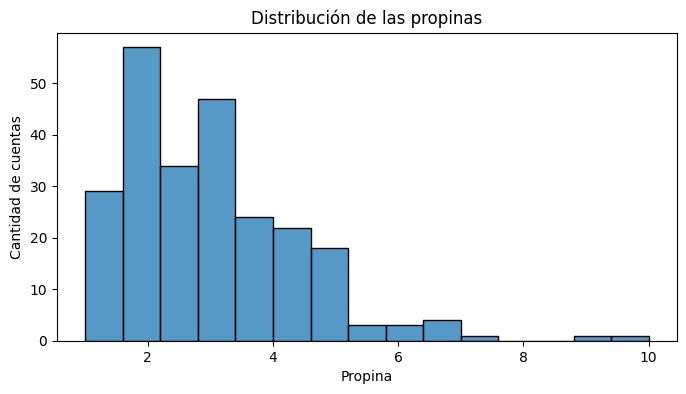

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="tip",
    bins=15
)

plt.title("Distribución de las propinas")
plt.xlabel("Propina")
plt.ylabel("Cantidad de cuentas")

plt.show()

El histograma muestra cómo se distribuyen los valores de `tip`.

La mayoría de las propinas se concentra aproximadamente entre 1 y 5. También se observa que las propinas altas son menos frecuentes. Hay pocos valores por encima de 6, y aparecen algunos casos aislados cercanos a 9 o 10.

Esto indica que la distribución tiene una cola hacia la derecha: muchos valores se agrupan en la zona baja o media, mientras que unos pocos valores más altos se alejan del grupo principal.

Esta lectura coincide con el resumen estadístico anterior:

- el promedio de propina es 3.00;
- la mediana es 2.90;
- el 75% de las propinas es menor o igual a 3.56;
- el valor máximo llega a 10.00.

Aunque el promedio y la mediana están bastante cerca, los valores altos siguen siendo importantes para entender la forma completa de la distribución.

## Boxplot de las propinas

Ahora vamos a visualizar la misma variable con un boxplot. El objetivo es observar de forma más compacta:

- dónde se ubica la mediana;
- entre qué valores se concentra la mitad central de las propinas;
- si aparecen posibles valores extremos.

Como ya vimos con `total_bill`, el boxplot no reemplaza al histograma. Nos ofrece otra mirada sobre la misma distribución.

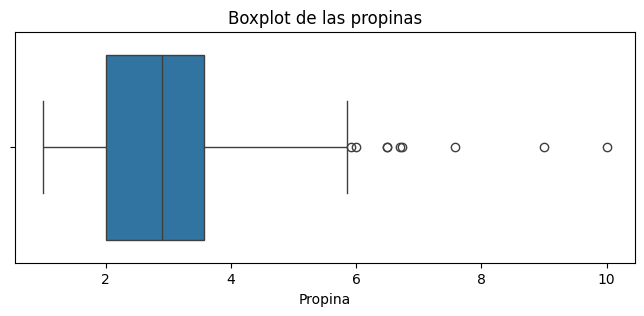

In [ ]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="tip"
)

plt.title("Boxplot de las propinas")
plt.xlabel("Propina")

plt.show()

El boxplot de `tip` resume la distribución de las propinas.

La caja se concentra aproximadamente entre 2.00 y 3.56, que son el primer y tercer cuartil que vimos en el resumen estadístico.

La línea dentro de la caja marca la mediana, que es 2.90.

Esto significa que la mitad central de las propinas se encuentra en un rango bastante acotado: entre 2.00 y 3.56.

También aparecen varios puntos hacia la derecha, por encima de los valores más habituales. Esos puntos representan posibles valores extremos.

En este caso, no necesariamente indican errores. Pueden ser propinas reales, pero más altas que la mayoría de las observaciones del dataset.

El boxplot confirma lo que ya mostraba el histograma: la mayoría de las propinas se concentra en valores bajos o medios, y hay unos pocos valores altos alejados del grupo principal.

## Comparar las distribuciones observadas

En este capítulo analizamos dos variables numéricas:

* `total_bill`, que representa el importe total de la cuenta;
* y `tip`, que representa la propina.

En ambos casos usamos el mismo recorrido:

* primero calculamos un resumen estadístico;
* después construimos un histograma;
* y finalmente usamos un boxplot.

Esto nos permitió ver que ambas variables tienen una distribución con cola hacia la derecha.

En otras palabras, hay muchos valores bajos o medios y pocos valores altos.

También vimos que los valores altos pueden influir en el promedio. Por eso, al analizar una distribución, conviene mirar el promedio junto con la mediana, los cuartiles y los posibles valores extremos.

## Qué aprendimos sobre histogramas y boxplots

Un histograma muestra la forma general de una distribución. Nos ayuda a ver dónde se concentran los valores, si hay zonas con muchos o pocos datos, y si la distribución se extiende más hacia un lado que hacia otro.

Un boxplot, en cambio, resume la distribución de manera más compacta. Nos permite identificar rápidamente la mediana, la mitad central de los datos y posibles valores extremos.

Estos dos gráficos no compiten entre sí. Se complementan. El histograma muestra mejor la forma de la distribución. El boxplot muestra mejor la síntesis de la distribución.

## Cuidado al interpretar valores extremos

En los boxplots vimos algunos puntos alejados del resto.Es importante interpretarlos con cuidado. Un valor extremo no significa automáticamente que haya un error en los datos. Puede ser:

* un dato real pero poco frecuente;
* una cuenta especialmente alta;
* una propina especialmente alta;
* o, en otros contextos, un posible error de carga o medición.

En análisis exploratorio, los valores extremos no se eliminan automáticamente. Primero se observan, se describen y, si es necesario, se investigan con más detalle.

## Cierre del capítulo

En este capítulo aprendimos a visualizar distribuciones de variables numéricas. Trabajamos con `total_bill` y `tip`, y usamos dos gráficos principales:

`histplot()`, para construir histogramas;

y `boxplot()`, para construir diagramas de caja.

También conectamos los gráficos con medidas de resumen como el promedio, la mediana, los cuartiles y el rango intercuartílico.

La idea central del capítulo fue que una variable numérica no se entiende completamente mirando solo un promedio.

Para analizarla mejor, necesitamos observar cómo se distribuyen sus valores.

En el próximo capítulo vamos a avanzar hacia otro tipo de pregunta: cómo visualizar comparaciones entre grupos o categorías.